## Tools Setup

In [95]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow as tf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Model
import tensorflow_datasets as tfds
from tiny_imagenet import TinyImagenetDataset

# Enable or disable GPU
# To fully disable it, we need to hide all GPU devices from Tensorflow
# Make sure GPU is disabled for this inference part of the lab
ENABLE_GPU = True
# tf.debugging.set_log_device_placement(True)

if not ENABLE_GPU:
    tf.config.set_visible_devices([], 'GPU')

# Print Python and TF version, and where we are running
print(f'Running on Python Version: {sys.version}')
print(f'Using Tensorflow Version: {tf. __version__}')
if not tf.config.experimental.list_physical_devices("GPU"):
    print('Running on CPU')
else:
    print(f'Using GPU at: {tf.test.gpu_device_name()} (of {len(tf.config.experimental.list_physical_devices("GPU"))} available)')

Running on Python Version: 3.9.21 (main, Feb 10 2025, 00:00:00) 
[GCC 11.5.0 20240719 (Red Hat 11.5.0-5)]
Using Tensorflow Version: 2.16.2
Running on CPU


## Dataset Inspection

In [96]:
# This cell imports our dataset.

# Original Source: https://github.com/ksachdeva/tiny-imagenet-tfds
# Class Version Source: https://github.com/duweisu/tiny-imagenet-tfds
# Setup our dataset
# ---------------------------------------------------------

tiny_imagenet_builder = TinyImagenetDataset()

# this call (download_and_prepare) will trigger the download of the dataset
# and preparation (conversion to tfrecords)
#
# This will be done only once and on next usage tfds will
# use the cached version on your host.
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

# class_names = tiny_imagenet_builder.info.features['label'].names
ds = tiny_imagenet_builder.as_dataset()
ds_train, ds_val = ds["train"], ds["validation"]
assert(isinstance(ds_train, tf.data.Dataset))
assert(isinstance(ds_val, tf.data.Dataset))

# Training Dataset
ds_train = ds_train.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
ds_val = ds_val.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Dataset metadata
ds_info = tiny_imagenet_builder.info

In [97]:
# We need to read the "human readable" labels so we can translate with the numeric values
# Read the labels file (words.txt)
with open(os.path.abspath('wnids.txt'), 'r') as f:
    wnids = [x.strip() for x in f]

# Map wnids to integer labels
wnid_to_label = {wnid: i for i, wnid in enumerate(wnids)}
label_to_wnid = {v: k for k, v in wnid_to_label.items()}

# Use words.txt to get names for each class
with open(os.path.abspath('words.txt'), 'r') as f:
    wnid_to_words = dict(line.split('\t') for line in f)
    for wnid, words in wnid_to_words.items():
        wnid_to_words[wnid] = [w.strip() for w in words.split(',')]
        
class_names = [str(wnid_to_words[wnid]) for wnid in wnids]

In [98]:
# Helper function to get the label name
def img_class(img_data, idx=None):
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    # Handle batches of images correctly
    if idx != None:
        image, label, id, label_name = img_data["image"][idx], img_data["label"][idx], img_data["id"][idx], img_data["metadata"]['label_name'][idx]
    
    return f"{label_name} (class index: {label} - id: {id})"


# Helper function to show basic info about an image
def img_info(img, idx=None, display=True, title_apend=""):
    image = img['image']

    # Print the class
    class_str = img_class(img, idx)
    print(f"Label: {class_str}")
    
    # Display the image
    if display:
        plt.figure()
        plt.title(title_apend + class_str)
        # Handle batches correctly
        if image.shape.ndims > 3:
            plt.imshow(image.numpy().reshape(64, 64, 3))
        else:
            plt.imshow(image.numpy())

--- Train & Validation dataset info ---
Train: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>
Validation: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>

--- Show an example image ---
Label: b'sulphur butterfly, sulfur butterfly' (class index: 42 - id: b'n02281406')

 Show some other examples


2025-09-22 14:22:52.786285: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-22 14:22:52.795337: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-22 14:22:52.891584: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

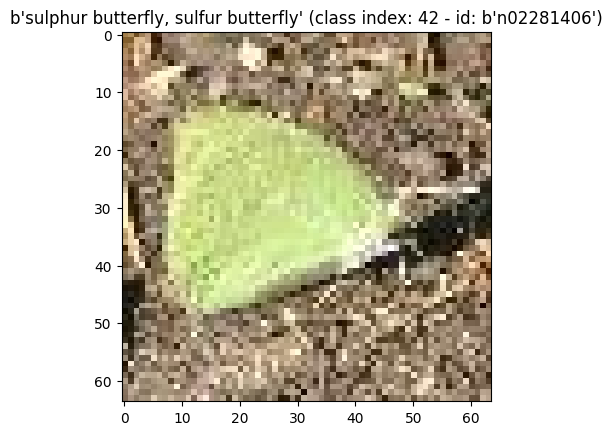

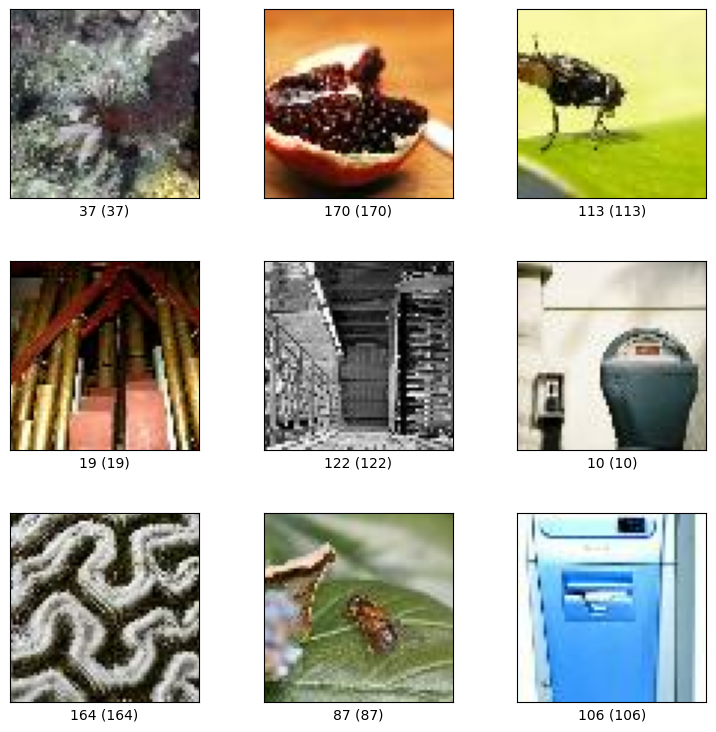

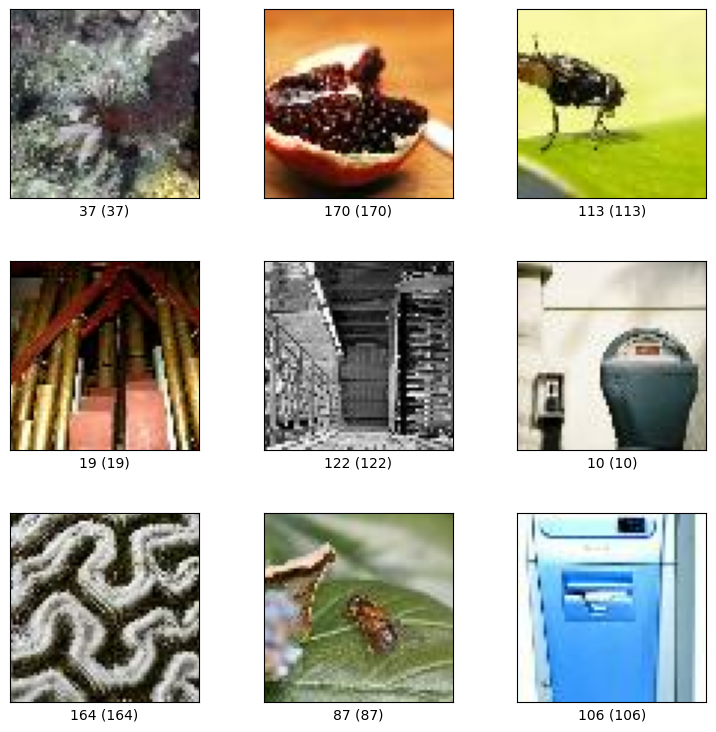

In [99]:
# Print the dataset types and info
print("--- Train & Validation dataset info ---")
print(f"Train: {ds_train}")
print(f"Validation: {ds_val}")
# print(f"Dataset Info: {ds_info}") # Uncomment to print Dataset info

print("\n--- Show an example image ---")
for example in ds_val.take(1):
    img_info(example)

print("\n Show some other examples")
tfds.show_examples(ds_val, ds_info, rows=3, cols=3)


--- Image 0 ---
Label: b'cannon' (class index: 80 - id: b'n02950826')
Image Shape - (64, 64, 3)
Image Dimensions - 3
Image Storage - <dtype: 'uint8'>
Label Index - 80
Id - b'n02950826'
Size - 12288 Bytes

--- Image 1 ---
Label: b'police van, police wagon, paddy wagon, patrol wagon, wagon, black Maria' (class index: 90 - id: b'n03977966')
Image Shape - (64, 64, 3)
Image Dimensions - 3
Image Storage - <dtype: 'uint8'>
Label Index - 90
Id - b'n03977966'
Size - 12288 Bytes

--- Image 2 ---
Label: b'bullet train, bullet' (class index: 69 - id: b'n02917067')
Image Shape - (64, 64, 3)
Image Dimensions - 3
Image Storage - <dtype: 'uint8'>
Label Index - 69
Id - b'n02917067'
Size - 12288 Bytes


2025-09-22 14:22:53.476892: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-22 14:22:53.482709: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


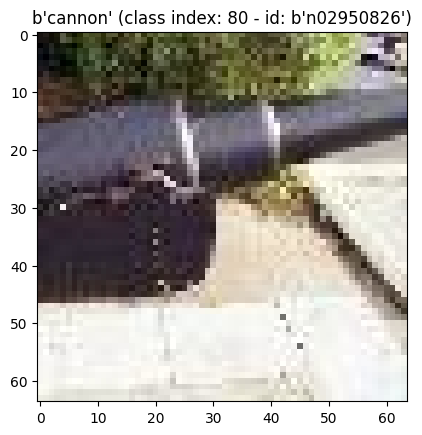

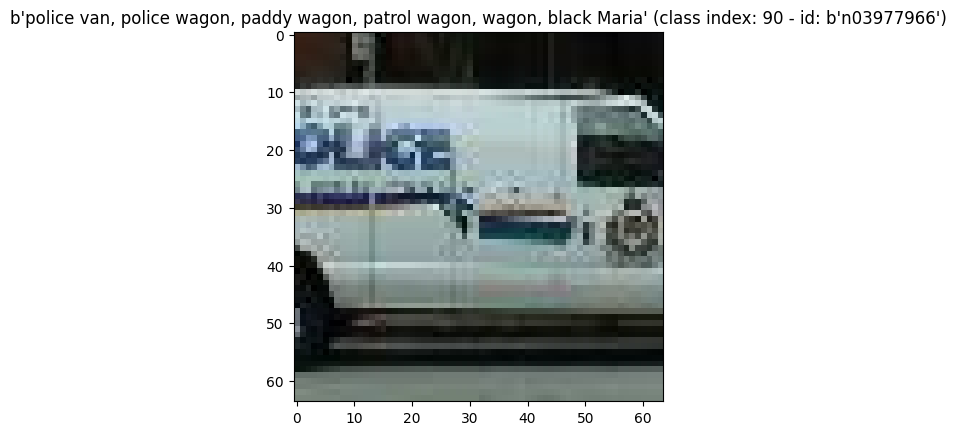

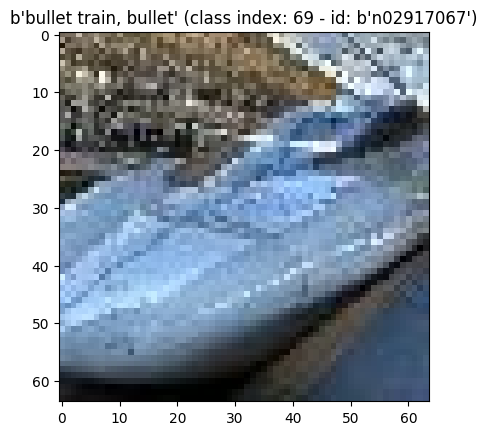

In [100]:
# TODO: Print and visualize three inputs from the validation set
#     : Print the stroage data type
#     : Print and note the dimensions of each image
#     : Print the memory required to store each image

# Sample Images
sample_imgs = []
for index, img_data in enumerate(ds_val.take(3)):
    sample_imgs.append(img_data)
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']

    print(f'\n--- Image {index} ---')
    # TODO: Your Code Here
    # See example usage: https://github.com/duweisu/tiny-imagenet-tfds
    img_info(img_data) # Print name of image as well as visualization
    #print(f"{image}")
    print(f"Image Shape - {image.shape}") # All images appear to be 3 dim
    print(f"Image Dimensions - {len(image.shape)}")
    print(f"Image Storage - {image.dtype}")
    print(f"Label Index - {label.numpy()}")
    print(f"Id - {id.numpy()}")
    print(f"Size - {image.shape[0] * image.shape[1] * image.shape[2]} Bytes") # could do a loop here for more consistency with larger matrices...

In [101]:
# TODO: Export each of the three inputs to a binary file which will be used to load the images into C++ later
# NOTE: First flatten the array (ex: 4D --> 1D). So 64*64*3 = 12288 element 1D array

# Make a directory for our image data
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

# Create a metadata file
with open(os.path.join(img_dir, 'metadata.txt'), 'w') as metadata_file:
    metadata_file.write('Number\t\tDims\t\tClass Data\n')

for index, img_data in enumerate(sample_imgs):    

    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    img_flat = image.numpy().flatten()
    
    # print index, shape and flattened length
    print(f"Image {index} shape: {image.shape}, flattened length: {len(img_flat)}")
    
    # 'wb' is write as a binary file
    with open(os.path.join(img_dir, f'image_{index}.bin'), 'wb') as img_file:
        img_flat.tofile(img_file)
    
    # 'a' mode in python is appending
    with open(os.path.join(img_dir, 'metadata.txt'), 'a') as metadata_file:
        metadata_file.write(f'{index}\t\t{image.shape}\t\t{label_name}\n')

Image 0 shape: (64, 64, 3), flattened length: 12288
Image 1 shape: (64, 64, 3), flattened length: 12288
Image 2 shape: (64, 64, 3), flattened length: 12288


## Model Loading and Inference

In [102]:
# TODO: Load the model
# Now we will load the H5 model! Please make sure the h5 model file is present in the below directory.
# You can download this from the Canvas Page and place it in the same directory as this notebook.

# model_path = os.path.abspath(""/home/<NETID>/path/to/your/lab1/CNN_TinyImageNet.h5)" # Uncomment this to use a non-relative path
model_path = os.path.abspath("CNN_TinyImageNet.h5")

# TODO: Your Code Here
model = tf.keras.models.load_model(model_path)
model.summary()

/home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/lab3_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/lab3_venv/lib64/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,218 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Label: [b'poncho'] (class index: [178] - id: [b'n03980874'])


2025-09-22 14:22:53.877439: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


2025-09-22 14:22:53.988100: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Best Guess [class index]: ['poncho'] [178]
Best Guess Confidence (percent / 1.0): [0.61238074]
Top 15 Guesses (class index): ["['poncho'] [178]", "['cardigan'] [31]", "['apron'] [134]", "['cauliflower'] [198]", "['sock'] [47]", '[\'spider web\', "spider\'s web"] [36]', "['umbrella'] [18]", "['vestment'] [104]", "['water jug'] [118]", "['sea slug', 'nudibranch'] [165]", "['backpack', 'back pack', 'knapsack', 'packsack', 'rucksack', 'haversack'] [38]", "['lampshade', 'lamp shade'] [61]", "['bucket', 'pail'] [190]", "['Christmas stocking'] [123]", "['fountain'] [140]"]
Top 15 Guesses Confidence (percent / 1.0): [[0.61238074 0.14417708 0.08776689 0.06362058 0.05356489 0.0065315
  0.00574364 0.00351701 0.00294049 0.00274844 0.0015809  0.0011642
  0.00108804 0.00096097 0.00078454]]


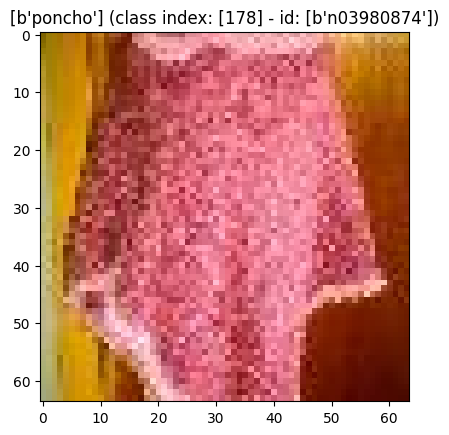

In [103]:
# Running infrence on our model
# We can run an infrence of our model by doing the following (we are doing batches of 1 here)
for example in ds_train.batch(1).take(1):
    img_info(example)
    
    # Make a prediction
    pred = model.predict(tf.cast(example["image"], tf.float32)/255.0)
    # print(f'Raw 200 Class Weighted Prediction:\n{pred}') # Uncomment to see the raw prediction
    
    # What is out best guess?
    best_guess = tf.math.argmax(pred, axis=1).numpy() # Our output is 200 weighted value, we want the most likely
    print(f'Best Guess [class index]: {class_names[best_guess[0]]} [{best_guess[0]}]')
    print(f'Best Guess Confidence (percent / 1.0): {pred[0][best_guess]}')

    # What are our top 15 guesses?
    top_15 = tf.math.top_k(pred, k=15)
    print(f'Top 15 Guesses (class index): {[f"{class_names[idx]} [{idx}]" for idx in top_15.indices[0]]}')
    print(f'Top 15 Guesses Confidence (percent / 1.0): {top_15.values}')

------------- Image 1 ----
Label: b'cannon' (class index: 80 - id: b'n02950826')
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Best Guess [class index]: ['frying pan', 'frypan', 'skillet'] [86]
Best Guess Confidence (percent / 1.0): [0.23722416]
Top 15 Guesses (class index): ["['frying pan', 'frypan', 'skillet'] [86]", "['goose'] [67]", "['tabby', 'tabby cat'] [66]", '["potter\'s wheel"] [96]', "['sombrero'] [82]", "['computer keyboard', 'keypad'] [26]", "['sewing machine'] [129]", "['wok'] [95]", "['space heater'] [30]", "['desk'] [85]", "['sunglasses', 'dark glasses', 'shades'] [112]", "['teapot'] [71]", "['CD player'] [70]", "['water jug'] [118]", "['stopwatch', 'stop watch'] [137]"]
Top 15 Guesses Confidence (percent / 1.0): [[0.23722416 0.15825577 0.04297156 0.03119076 0.02835155 0.02774745
  0.02459977 0.02446754 0.02031882 0.01960657 0.01801447 0.01740959
  0.01552101 0.0150551  0.01245399]]
------------- Image 2 ----
Label: b'police van, police wagon, paddy wagon, patrol wagon, wagon, 

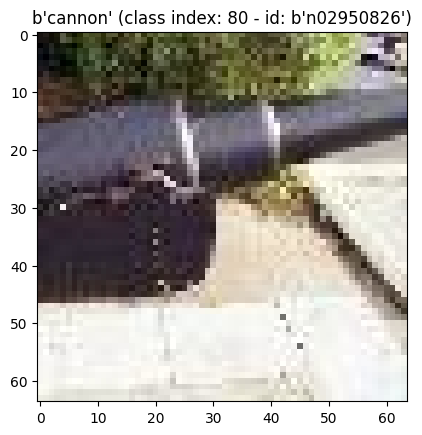

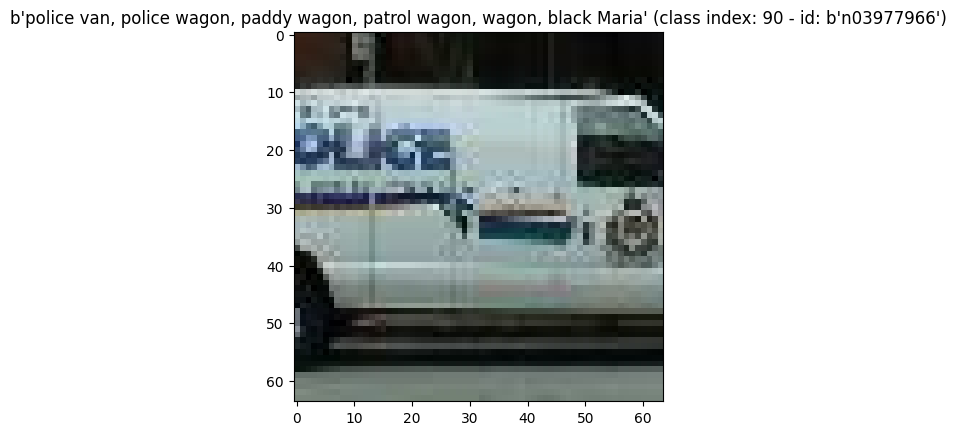

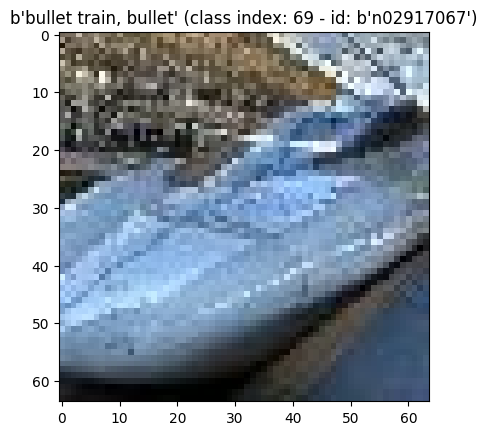

In [104]:
# TODO: Run infrence for our previous 3 sample images

# TODO: Your Code Here


for index, img_data in enumerate(sample_imgs): 
    print(f"------------- Image {index+1} ----")
    img_info(img_data)
    img = sample_imgs[index]["image"]
    normalized = tf.cast(img, tf.float32) / 255.0
    normalized = tf.expand_dims(normalized, axis=0)
    pred = model.predict(normalized)

    # What is out best guess?
    best_guess = tf.math.argmax(pred, axis=1).numpy() # Our output is 200 weighted value, we want the most likely
    print(f'Best Guess [class index]: {class_names[best_guess[0]]} [{best_guess[0]}]')
    print(f'Best Guess Confidence (percent / 1.0): {pred[0][best_guess]}')

    # What are our top 15 guesses?
    top_15 = tf.math.top_k(pred, k=15)
    print(f'Top 15 Guesses (class index): {[f"{class_names[idx]} [{idx}]" for idx in top_15.indices[0]]}')
    print(f'Top 15 Guesses Confidence (percent / 1.0): {top_15.values}')
    
    

In [105]:
# TODO: Calculate the Top-1, Top-5, and Top-10 Accuracy of the validation dataset
total = acc_top1 = acc_top5 = acc_top10 = 0
top1_correct = top5_correct = top10_correct = total_images = 0

total_images = 0

batch_size = 256

#ds_val = ds_val.batch(batch_size)
#ds_val = ds_val.prefetch(tf.data.AUTOTUNE)

# TODO: Your Code Here
for batch in ds_val.batch(batch_size).take(10000 // batch_size + 1):
    if(total_images >= 10000):
        break

    #print(f"images analyzed: {total_images}\n")
    images = batch["image"]
    labels = batch["label"]
    images = tf.cast(images, tf.float32) / 255.0

    #images = tf.expand_dims(images, axis=0)

    #pred = model.predict(tf.cast(example["image"], tf.float32)/255.0)
    # Make a prediction
    pred = model.predict(images, verbose=0)

    # Convert labels to int32 if one-hot encoded
    if len(labels.shape) > 1:  # Check if labels are one-hot
        labels = tf.argmax(labels, axis=1)
    labels = tf.cast(labels, tf.int32)  # Shape: (batch_size,)

    labels = tf.expand_dims(labels, axis=1)  # Shape: (batch_size, 1)

    #get correct counts

    top10 = tf.math.top_k(pred, k=10)
    top10_indices = top10.indices

    top1_matches = tf.reduce_any(tf.equal(labels, top10_indices[:, :1]))
    top1_correct += tf.reduce_sum(tf.cast(top1_matches, tf.int32)).numpy() 

    # Top-5 accuracy: True label in top-5 predictions
    top5_matches = tf.reduce_any(tf.equal(labels, top10_indices[:, :5]), axis=1)
    top5_correct += tf.reduce_sum(tf.cast(top5_matches, tf.int32)).numpy()
    
    # Top-10 accuracy: True label in top-10 predictions
    top10_matches = tf.reduce_any(tf.equal(labels, top10_indices), axis=1)
    top10_correct += tf.reduce_sum(tf.cast(top10_matches, tf.int32)).numpy()
    
    # Update total images
    total_images += batch_size

print(f"Total Images: {total_images}\n")
acc_top1 = top1_correct / total_images
acc_top5 = top5_correct / total_images
acc_top10 = top10_correct / total_images

total = (acc_top1 + acc_top5 + acc_top10) / 3.0

print(f"Top 1 Accuracy : {acc_top1 * 100.0}\n")
print(f"Top 5 Accuracy : {acc_top5 * 100.0}\n")
print(f"Top 10 Accuracy : {acc_top10 * 100.0}\n")
print(f"Total Accuracy : {total * 100.0}\n")

    

    
    



Total Images: 10240

Top 1 Accuracy : 0.390625

Top 5 Accuracy : 48.2421875

Top 10 Accuracy : 60.29296875

Total Accuracy : 36.30859375



2025-09-22 14:23:01.004241: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [106]:
# TODO: Print all of the possible classes of the dataset

# TODO: Your Code Here
train_labels = ds_train.map(lambda x: x['label']).batch(len(ds_train)).as_numpy_iterator().next()

print("classes in training dataset:\n")
print(np.unique(train_labels))

val_labels = ds_val.map(lambda x: x['label']).batch(len(ds_val)).as_numpy_iterator().next()

print("\nclasses in validation dataset:\n")
print(np.unique(val_labels))

classes in training dataset:

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]

classes in validation dataset:

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  3

## Model Exploration

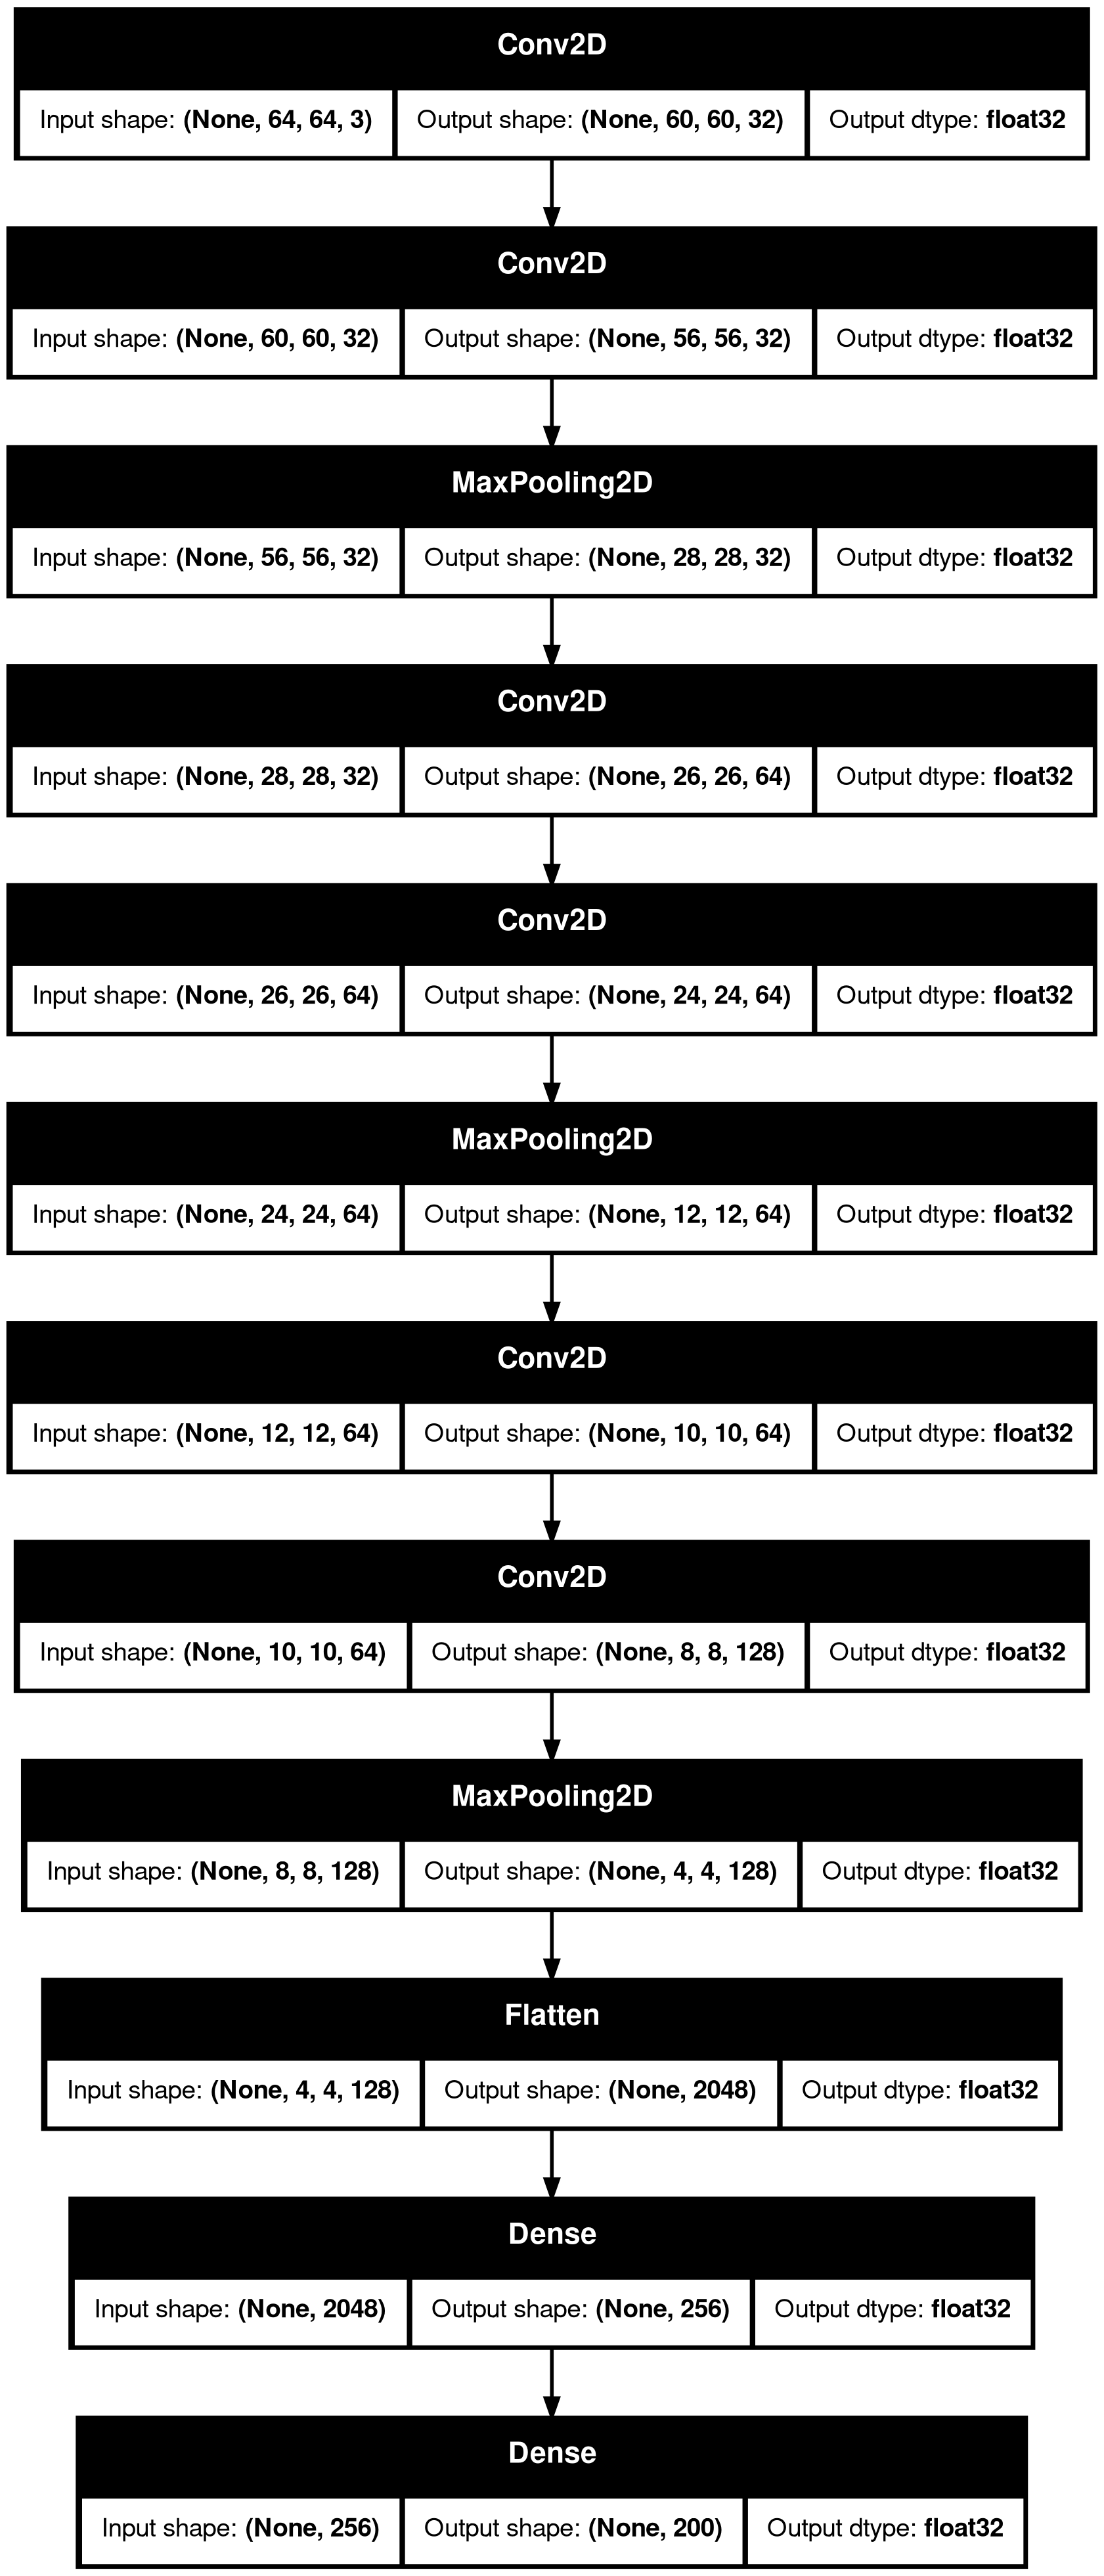

In [107]:
# TODO: Visualize the model in Netron (https://netron.app/) and include an image here.
tf.keras.utils.plot_model(model, "model.png", show_shapes=True, show_dtype=True, expand_nested=True) # Uncomment this to generate a simple visualization

conv2d: float32, Shape: (5, 5, 3, 32), Memory: 9.38 KB
conv2d_5: float32, Shape: (3, 3, 64, 128), Memory: 288.00 KB


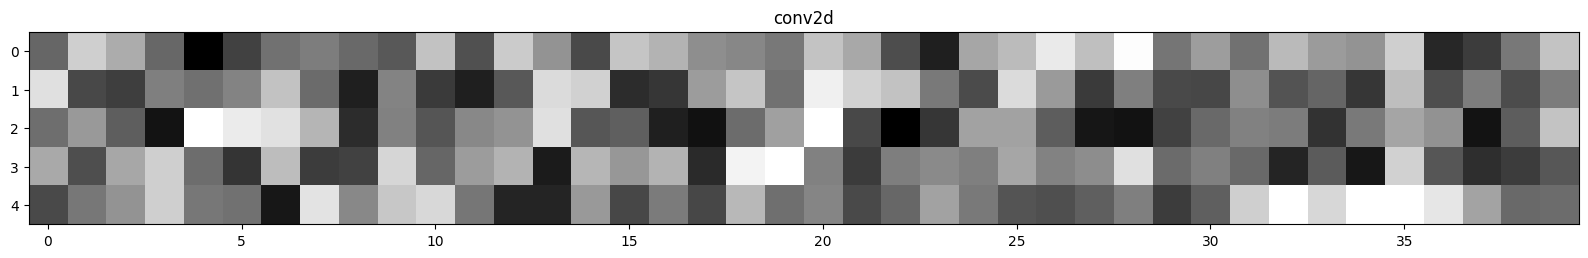

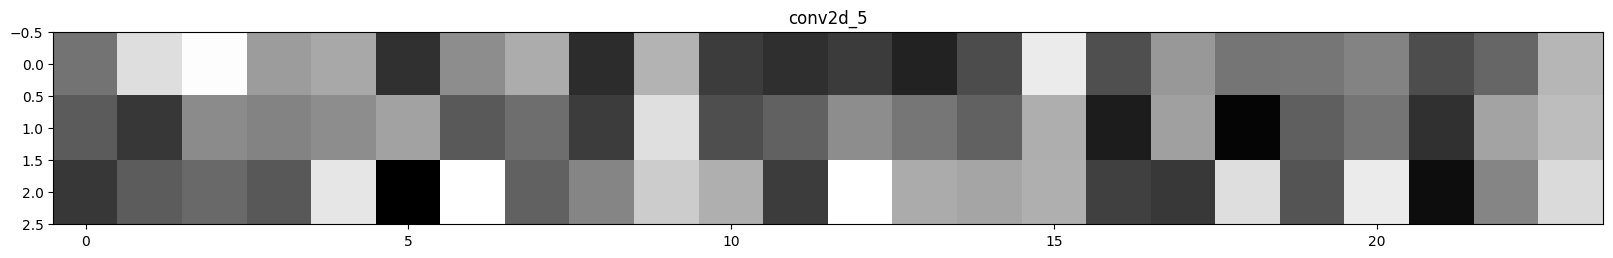

In [108]:
# We can view the layer weights. Here we consider them as images of feature filters applied to intermediate feature map images.
# TODO: Visualize the 2 convolutional layers filter sets (weights) (one at the beginning and one at the end)

# TODO: Your Code Here

layers = [layer for layer in model.layers]

first_layer, last_layer = layers[0], layers[-5] # first and last conv layer
first_weights, last_weights = first_layer.get_weights()[0], last_layer.get_weights()[0]

# vosializes the kernels in a belt form
def visualize_kernels(weights, layer_name):
    height, width, in_channels, out_channels = weights.shape # for weights we can just use shape outchannel (maybe we are meant to use the inchannel but idk for sure it's comprable)
    k = min(out_channels, 8) # min 8 increases the size for easier readability
    size = height
    
    # we need an empty belt (getting this right took forever)
    image_belt = np.zeros((size, size * k), dtype=np.uint8) # Image belt initialization credit to: Grok 3 (Debugged and initialized) [this wasn't included in the article >:(]
    
    # # from alayticsvidhya article
    for i in range(k):
        feature_image = np.mean(weights[:, :, :, i], axis=2) # axis 2 has weights
        feature_image -= feature_image.mean() 
        feature_image /= feature_image.std()
        feature_image *= 64
        feature_image += 128
        feature_image = np.clip(feature_image, 0, 255).astype('uint8')
        image_belt[:, i * size : (i + 1) * size] = feature_image
    
    # Print belt (from analyticsvidya article)
    scale = 20. / k
    plt.figure(figsize=(scale * k, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(image_belt, cmap='gray', aspect='auto')

# do both layers
visualize_kernels(first_weights, first_layer.name)
visualize_kernels(last_weights, last_layer.name)

#   print weigt details
def print_weight_details(weights, layer_name):
    dtype, shape = weights.dtype, weights.shape
    num_params = np.prod(shape)
    memory_bytes = num_params * 4
    print(f"{layer_name}: {dtype}, Shape: {shape}, Memory: {memory_bytes / 1024:.2f} KB")

print_weight_details(first_weights, first_layer.name)
print_weight_details(last_weights, last_layer.name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
conv2d: float32, Shape: (5, 5, 3, 32), Memory: 9.38 KB
conv2d_1: float32, Shape: (5, 5, 32, 32), Memory: 100.00 KB
conv2d_2: float32, Shape: (3, 3, 32, 64), Memory: 72.00 KB
conv2d_3: float32, Shape: (3, 3, 64, 64), Memory: 144.00 KB
conv2d_4: float32, Shape: (3, 3, 64, 64), Memory: 144.00 KB
conv2d_5: float32, Shape: (3, 3, 64, 128), Memory: 288.00 KB
dense: float32, Shape: (2048, 256), Memory: 2048.00 KB
dense_1: float32, Shape: (256, 200), Memory: 200.00 KB


/tmp/ipykernel_27800/3795407857.py:17: RuntimeWarning: invalid value encountered in divide
  feature_image/= feature_image.std ()
/tmp/ipykernel_27800/3795407857.py:20: RuntimeWarning: invalid value encountered in cast
  feature_image= np.clip(feature_image, 0, 255).astype('uint8')
2025-09-22 14:23:02.993604: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


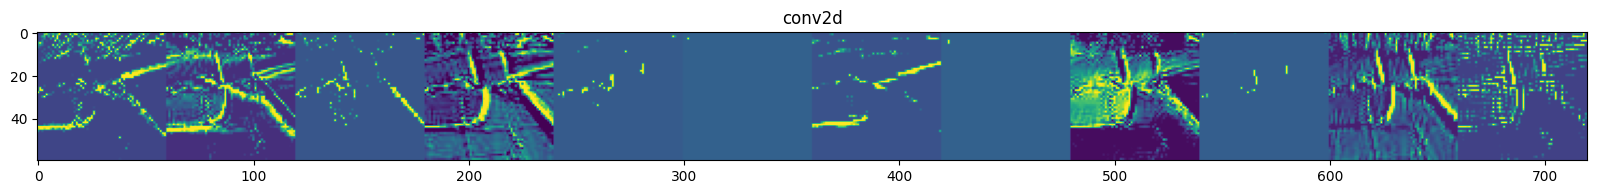

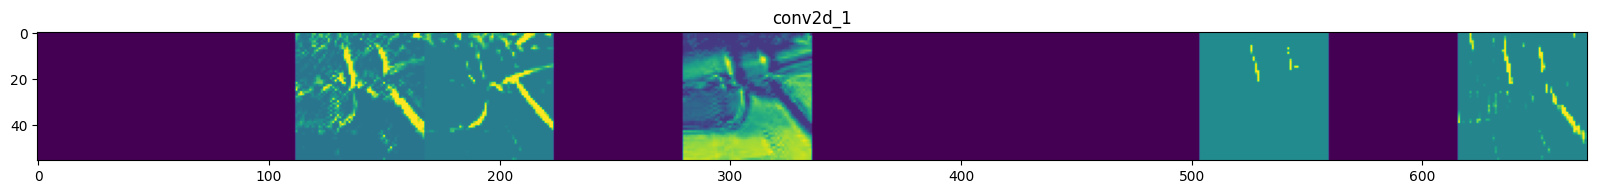

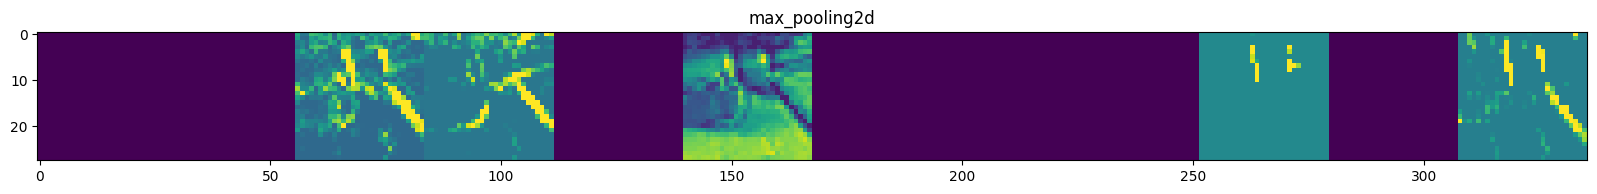

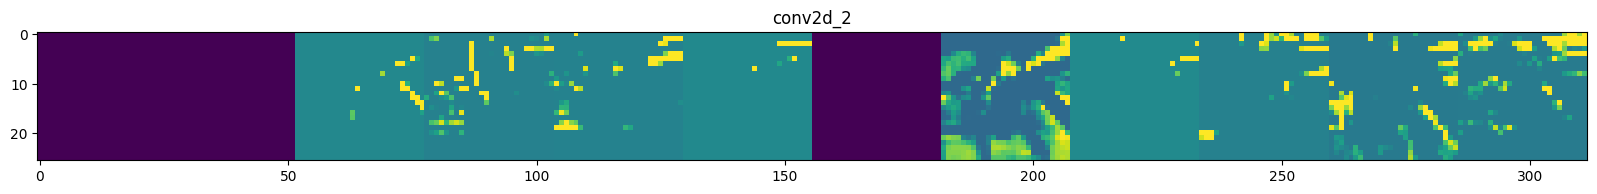

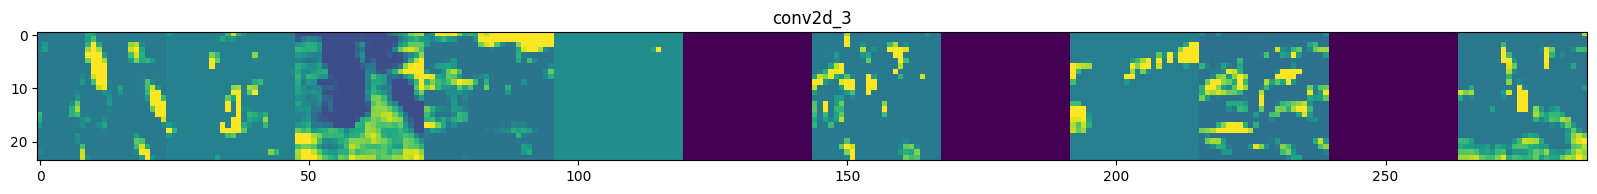

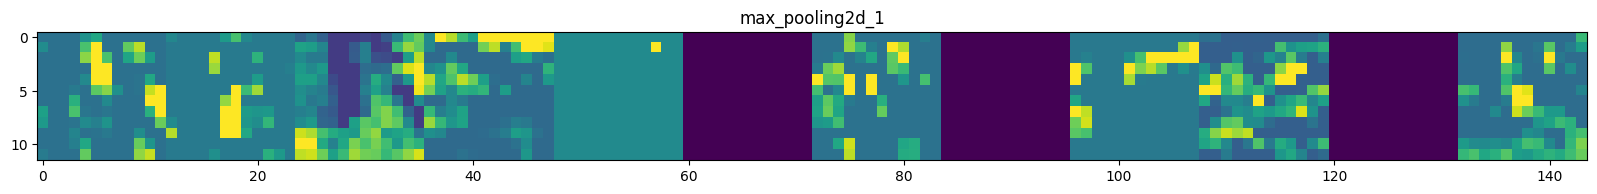

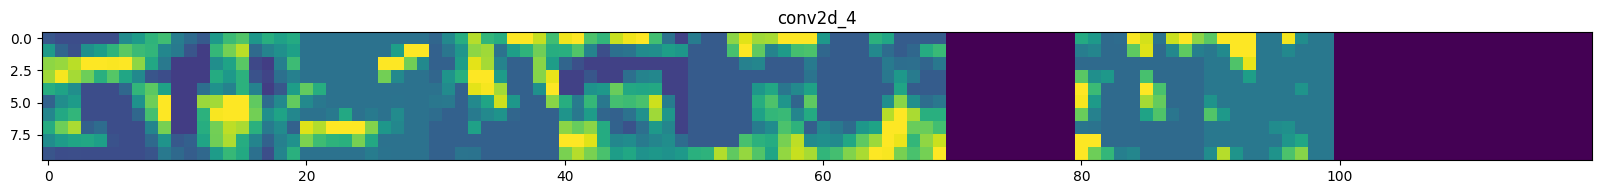

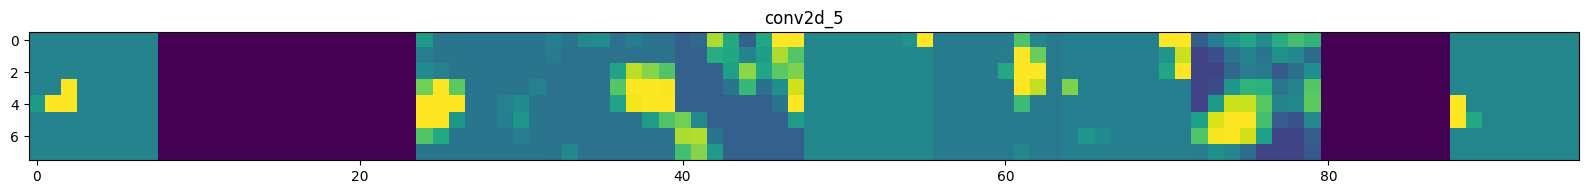

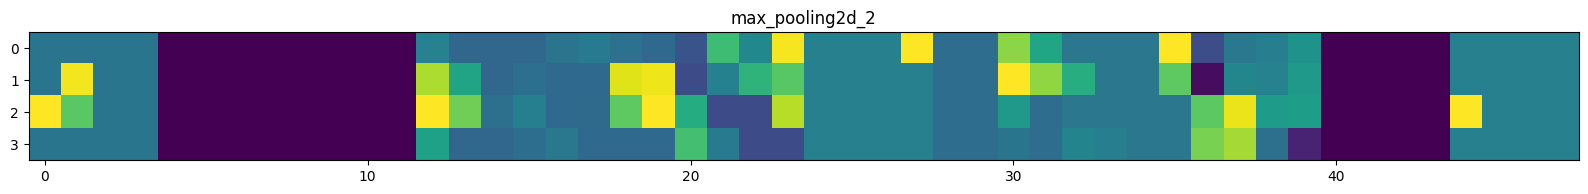

In [109]:
# We can view the layer outputs as well. Here we consider them as images of the spatial location of features.
# TODO: Visualize the 2 convolutional layers outputs (intermediate feature maps) (one at the beginning and one at the end)

# TODO: Your Code Here
def visualize_features(layer_name, feature_map): 
    for layer_name, feature_map in zip(layer_names, feature_maps): # Number of feature images/dimensions in a feature map of a layer 
        if len(feature_map.shape) != 4: 
            return
        k = min(feature_map.shape[-1], 12)  # Limit to 12 for readability
        size=feature_map.shape[1]
        image_belt = np.zeros((size, size * k), dtype=np.uint8)
    
        #iterating over a feature map of a particular layer to separate all feature images.    for i in range(k):
        for i in range(k):
            feature_image = feature_map[0, :, :, i]
            feature_image-= feature_image.mean()
            feature_image/= feature_image.std ()
            feature_image*=  64
            feature_image+= 128
            feature_image= np.clip(feature_image, 0, 255).astype('uint8')
            image_belt[:, i * size : (i + 1) * size] = feature_image

        scale = 20. / k
        plt.figure( figsize=(scale * k, scale) )
        plt.title ( layer_name )
        plt.grid  ( False )
        plt.imshow( image_belt, aspect='auto')


# get an image from ds_val


layer_names = [layer.name for layer in model.layers]
layer_outputs = [layer.output for layer in model.layers]



feature_map_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

for batch in ds_val.batch(1).take(1):
    input_img = batch["image"]
    input_img = tf.cast(input_img, tf.float32) / 255.0
    feature_maps = feature_map_model.predict(input_img)
    visualize_features(layer_names[4], feature_maps[4])

#   print weigt details
def print_weight_details(weights, layer_name):
    dtype, shape = weights.dtype, weights.shape
    num_params = np.prod(shape)
    memory_bytes = num_params * 4
    print(f"{layer_name}: {dtype}, Shape: {shape}, Memory: {memory_bytes / 1024:.2f} KB")

for layer in model.layers:
    if len(layer.get_weights()) == 0:
        continue
    weights = layer.get_weights()[0]
    layer_name = layer.name
    print_weight_details(weights, layer_name)


In [110]:
# TODO: Export the filters/weights se we can use them later
# Make a directory for our image data
model_dir = os.path.abspath('model_data')
pathlib.Path(model_dir).mkdir(exist_ok=True)


# Export each image
conv_index = dense_index = 1 # layer index starts from one
for layer_idx, layer in enumerate(model.layers):
    if re.match(r'(conv|dense)', layer.name):
        weight_file_name = os.path.join(model_dir, f'{layer.name}_weights.bin')
        bias_file_name = os.path.join(model_dir, f'{layer.name}_bias.bin')
    else: continue

    assert layer.weights[0].name.endswith('kernel')
    assert layer.weights[1].name.endswith('bias')
        
    # TODO: Your Code Here
    weights = layer.get_weights()[0]
    biases = layer.get_weights()[1]
    weights_flat = weights.flatten()
    biases_flat = biases.flatten()
    with open(weight_file_name, 'wb') as weight_file:
        weights_flat.tofile(weight_file)
    with open(bias_file_name, 'wb') as bias_file:
        biases_flat.tofile(bias_file)
    print(f"Exported {layer.name} weights to {weight_file_name} and biases to {bias_file_name}")

Exported conv2d weights to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_weights.bin and biases to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_bias.bin
Exported conv2d_1 weights to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_1_weights.bin and biases to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_1_bias.bin
Exported conv2d_2 weights to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_2_weights.bin and biases to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_2_bias.bin
Exported conv2d_3 weights to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_3_weights.bin and biases to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_3_bias.bin
Exported conv2d_4 weights to /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/model_data/conv2d_4_weights.bin and biases to /h

In [111]:
# # TODO: Export the intermediate layer outputs for each input image for all layers
# img_dir = os.path.abspath('img_data')
# pathlib.Path(img_dir).mkdir(exist_ok=True)

# # Create a model that outputs all intermediate layers
# feature_map_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

# for img_idx, img_data in enumerate(sample_imgs):
#     file_dir = os.path.join(img_dir, f'test_input_{img_idx}')
#     pathlib.Path(file_dir).mkdir(exist_ok=True)

#     # prep image
#     img = img_data["image"]
#     input_img = tf.cast(img, tf.float32) / 255.0
#     input_img = tf.expand_dims(input_img, axis=0)
    
#     feature_maps = feature_map_model.predict(input_img)
    
#     #   flatten and export feature maps
#     for layer_idx, fmap in enumerate(feature_maps):
#         layer_name = layer_names[layer_idx]
#         fmap_flat = fmap.flatten()
#         out_path = os.path.join(file_dir, f'{layer_name}_output.bin')
#         with open(out_path, 'wb') as out_file:
#             fmap_flat.tofile(out_file)
#         print(f"exported {layer_name} output for image {img_idx} to {out_path}")

## Tensorboard

In [112]:
# Setup for profiling
tf.profiler.experimental.ProfilerOptions(
    host_tracer_level=1, python_tracer_level=0, device_tracer_level=1
)

log_dir = os.path.abspath(os.path.join('log_data'))
log_dir_run = os.path.abspath(os.path.join(log_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(log_dir_run).mkdir(exist_ok=True, parents=True)

try:
    tf.profiler.experimental.stop()
except:
    test = 2
finally:
    test = 1

In [113]:
# TODO: Sample Profiling - Inference for a single image:

# Define inference step with tf.function for optimization

# I dont know what the hell to do here...
# Issue resolved, was not looking at the toolflow tool dropdown

@tf.function
def inference_step(image):
    return model(image)

tf.profiler.experimental.start(log_dir_run)

for img_data in ds_val.take(3): 
    img = img_data["image"] 
    img = tf.cast(img, tf.float32) / 255.0 
    img = tf.expand_dims(img, axis=0)  
    inference_step(img)  
    print("image done")

tf.profiler.experimental.stop()

image done
image done
image done


2025-09-22 14:23:03.762347: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-22 14:23:03.762364: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-09-22 14:23:03.848685: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-22 14:23:03.849718: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-22 14:23:03.857913: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-22 14:23:03.859979: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/cam2022/CPRE-487_git/CPRE-4870/Lab 3/lab6_template/log_data/20250922-142303/plugins/profile/2025_09_22_14_23_03/co2050-18.ece.iastate.edu.xplane.pb


In [114]:
# Load the TensorBoard notebook extension.
# %load_ext tensorboard

# # Launch TensorBoard and navigate to the Profile tab to view performance profile. 
# # *** Please note just execute this command once in a session and 
# # then logs for subsequent runs would be auto detected in tensorboard- url: http://localhost:6006/
# print(log_dir_run)
# %tensorboard --logdir={log_dir_run} --port=6006

# # You can view the tensorboard in the browser url: http://localhost:6006/

# # Useful command line to have if tensorboard is misbehaving: kill $(ps -e | grep 'tensorboard' | awk '{print $1}')

In [115]:
# TODO: Sample Profiling - Online Inference:

# # Vary this from 10, 100, 1000 to simulate multiple online inference
# loop_index = [10, 100, 1000]

# for idx in loop_index:

#     tf.profiler.experimental.start(log_dir_run)

#     for i in range(idx):
#         # Actual online inference
#         # TODO: Your Code Here
#         for batch in ds_val.batch(1).take(1):
#             image = batch["image"]
#             image = tf.cast(image, tf.float32) / 255.0
#             pred = model.predict(image)

#     tf.profiler.experimental.stop() 




In [116]:
# # TODO: Sample Profiling - Batch Inference:

# # We would only perform batch inference for a subset of validation set i.e. 1000 images 
# # using different batch sizes of 20, 40, 100, 200 

# # Decides the size of the batch. Try: 20, 40, 100, 200
# batch_size = [20, 40, 100, 200]

# for batch in batch_size:
#     # Starts Profile logging
#     tf.profiler.experimental.start(log_dir_run)

#     for batch in ds_val.batch(batch).take(1000 // batch):
#         image = batch["image"]
#         image = tf.cast(image, tf.float32) / 255.0
#         pred = model.predict(image)

#     tf.profiler.experimental.stop() 

## Training

In [117]:
# Setup for model training
from tensorflow.keras import Model, datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, ZeroPadding2D,Convolution2D, Activation, Dropout 
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import TopKCategoricalAccuracy

train_dir = os.path.abspath(os.path.join('train_data', datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(train_dir).mkdir(exist_ok=True, parents=True)



# Using early stopping to monitor validation accuracy
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor="val_loss",
        # "no longer improving" being defined as "no better than 1e-2 less" CHANGED TO BE LESS SENSITIVE
        min_delta=1e-4,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=2,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(log_dir=train_dir, histogram_freq=1)
]

In [118]:
def new_model(): # CREATED THIS SO WE CAN GET NEW MODELS TO TRAIN FOR EACH NEW BATCH/EPOCH!!!
    # Basic CNN model
    train_model = Sequential()
    
    # conv1
    train_model.add(Conv2D(32, (5, 5), input_shape=(64, 64, 3), activation='relu'))
    train_model.add(Conv2D(32, (5,5),activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(Conv2D(128, (3,3), activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Flatten())
    
    # fc1
    train_model.add(Dense(256, activation='relu'))
    
    # fc2
    train_model.add(Dense(200, activation='softmax'))
    
    train_model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), metrics=['accuracy', TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]) #optimizer change to fix learning rate provided by Google Gemini 2.5 Flash
    # TODO: Consider looking at different optimizers and learning rate settings
    #train_model.summary() comment out for now
    return train_model

In [119]:
# # TODO: Attempt to train your own model with different batch sizes
# # TODO: See how long this takes without a GPU on your VDI or 2050 Coover machines
# # TODO: THEN log in to your GPU VM, set ENABLE_GPU = False in the very first cell, and re-run all above cells
# # TODO: Make sure you have exported the LD_LIBRARY_PATH as the lab manual indicates

# def normalize_img(image, label):
#     return tf.cast(image, tf.float32) / 255., label

# def to_categorical(image, label):
#     label = tf.one_hot(tf.cast(label, tf.int32), 200)
#     return tf.cast(image, tf.float32), tf.cast(label, tf.int64)

# ds_re = tiny_imagenet_builder.as_dataset(as_supervised=True)
# ds_retrain, ds_reval = ds_re["train"], ds_re["validation"]

# ds_retrain = ds_retrain.cache().shuffle(1024)
# ds_reval = ds_reval.cache().shuffle(1024)

# ds_retrain = ds_retrain.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
# ds_reval = ds_reval.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)

# ds_retrain = ds_retrain.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)
# ds_reval = ds_reval.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)

# epoch_size = 20

# best_top1 = {'batch_size': None, 'accuracy': 0.0}
# best_top5 = {'batch_size': None, 'accuracy': 0.0}

# for batch_size in [32, 64, 128]:
#     # Setup our batched datasets
#     print(f"\nTraining with batch size: {batch_size}")
#     # TODO: Your Code Here
#     train_dataset = ds_retrain.batch(batch_size).prefetch(tf.data.AUTOTUNE)
#     val_dataset = ds_reval.batch(batch_size).prefetch(tf.data.AUTOTUNE)

#     train_model = new_model()

#     history = train_model.fit(
#             train_dataset,
#             epochs=epoch_size,
#             validation_data=val_dataset,
#             callbacks=[callbacks], 
#             verbose=1
#         )
#     last_val_top1_accuracy = history.history['val_accuracy'][-1]
#     last_val_top5_accuracy = history.history['val_top_5_accuracy'][-1]
    
#     # Get best top-1 overall (kind of inaccurate as the val accuracy drops off as overfitting occurs)
#     if last_val_top1_accuracy > best_top1['accuracy']:
#         best_top1['accuracy'] = last_val_top1_accuracy
#         best_top1['batch_size'] = batch_size
    
#     # Update best Top-5 accuracy (kind of inaccurate as the val accuracy drops off as overfitting occurs)
#     if last_val_top5_accuracy > best_top5['accuracy']:
#         best_top5['accuracy'] = last_val_top5_accuracy
#         best_top5['batch_size'] = batch_size

# print("\nSummary of Best Accuracies:")
# print(f"Best Top-1 Validation Accuracy: {best_top1['accuracy']:.4f} (Batch Size: {best_top1['batch_size']})")
# print(f"Best Top-5 Validation Accuracy: {best_top5['accuracy']:.4f} (Batch Size: {best_top5['batch_size']})")


In [120]:
# # TODO: Train your model with 3 different numbers of epochs
# batch_size = 32

# # Setup your datasets
# # TODO: Your Code Here
# train_dataset = ds_retrain.batch(batch_size).prefetch(tf.data.AUTOTUNE)
# val_dataset = ds_reval.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# for epoch_size in [3, 10, 100]:
#     # Run training
#     # TODO: Your Code Here
#     train_model = new_model()

#     history = train_model.fit(
#             train_dataset,
#             epochs=epoch_size,
#             validation_data=val_dataset,
#             callbacks=[callbacks], 
#             verbose=1
#         )
   
#     # Save the cnn model
#     train_model.save(os.path.join(log_dir, f'CNN_TinyImageNet_train_batch{batch_size}.h5'))
#     last_val_top1_accuracy = history.history['val_accuracy'][-1]
#     last_val_top5_accuracy = history.history['val_top_5_accuracy'][-1]
    
#     # Update best Top-1 accuracy (kind of inaccurate as the val accuracy drops off as overfitting occurs)
#     if last_val_top1_accuracy > best_top1['accuracy']:
#         best_top1['accuracy'] = last_val_top1_accuracy
#         best_top1['batch_size'] = batch_size
    
#     # Update best Top-5 accuracy (kind of inaccurate as the val accuracy drops off as overfitting occurs)
#     if last_val_top5_accuracy > best_top5['accuracy']:
#         best_top5['accuracy'] = last_val_top5_accuracy
#         best_top5['batch_size'] = batch_size

# # Report the best overall accuracies
# print("\nSummary of Best Accuracies:")
# print(f"Best Top-1 Validation Accuracy: {best_top1['accuracy']:.4f} (Batch Size: {best_top1['batch_size']})")
# print(f"Best Top-5 Validation Accuracy: {best_top5['accuracy']:.4f} (Batch Size: {best_top5['batch_size']})")

## Histogram

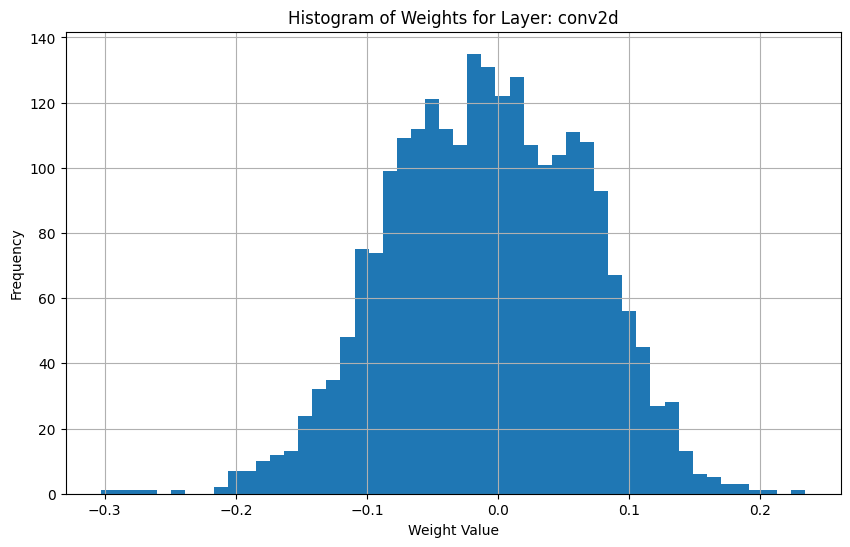

conv2d: float32, Shape: (5, 5, 3, 32), Memory: 9.38 KB


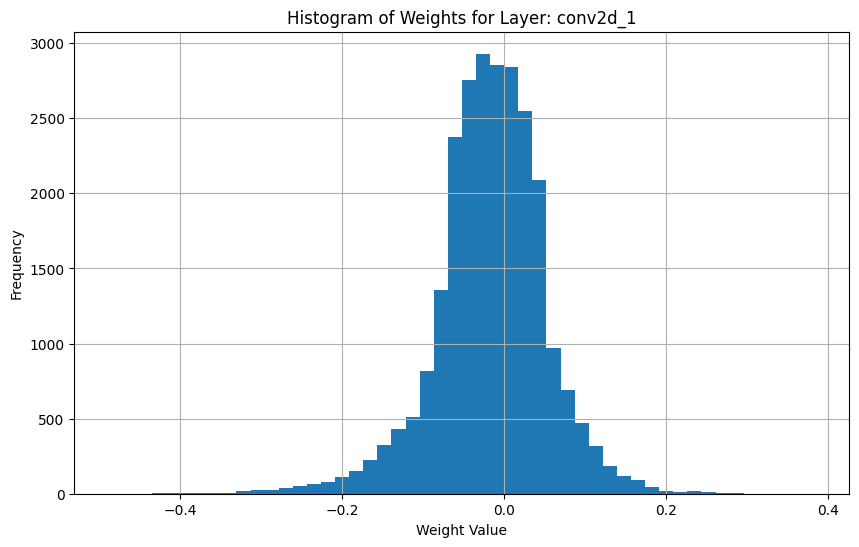

conv2d_1: float32, Shape: (5, 5, 32, 32), Memory: 100.00 KB


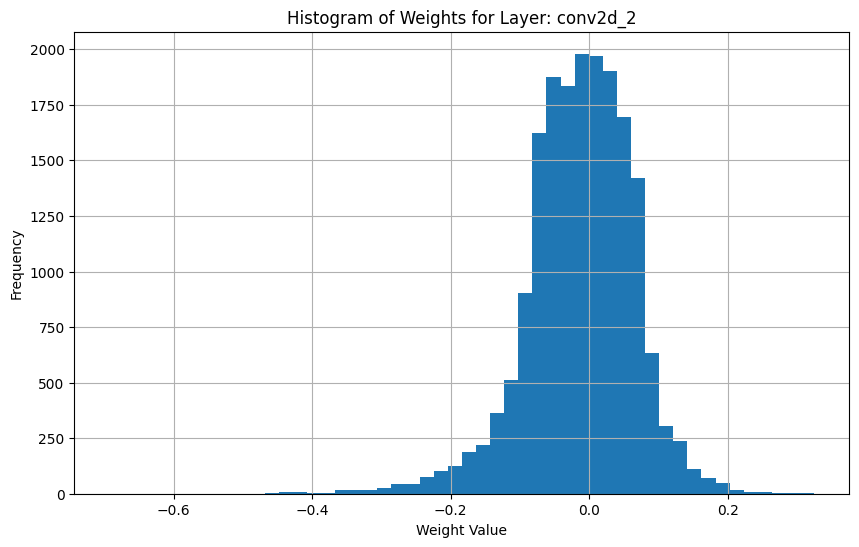

conv2d_2: float32, Shape: (3, 3, 32, 64), Memory: 72.00 KB


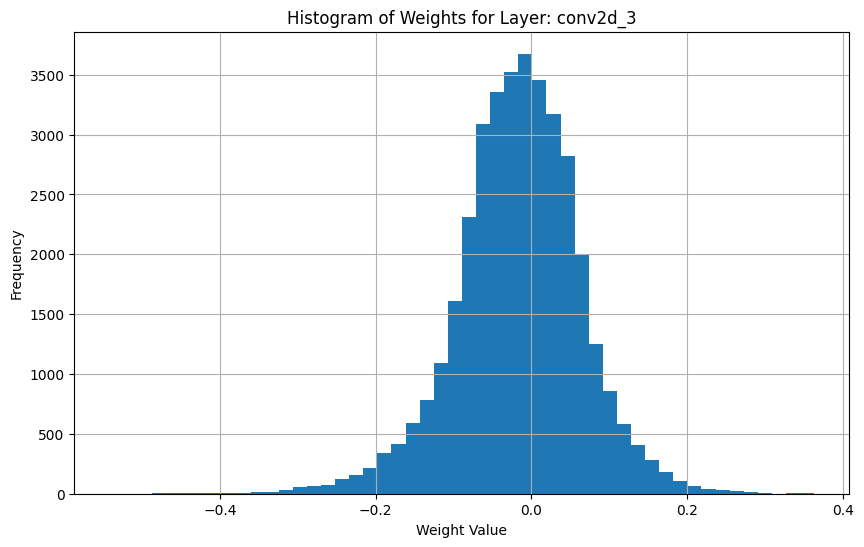

conv2d_3: float32, Shape: (3, 3, 64, 64), Memory: 144.00 KB


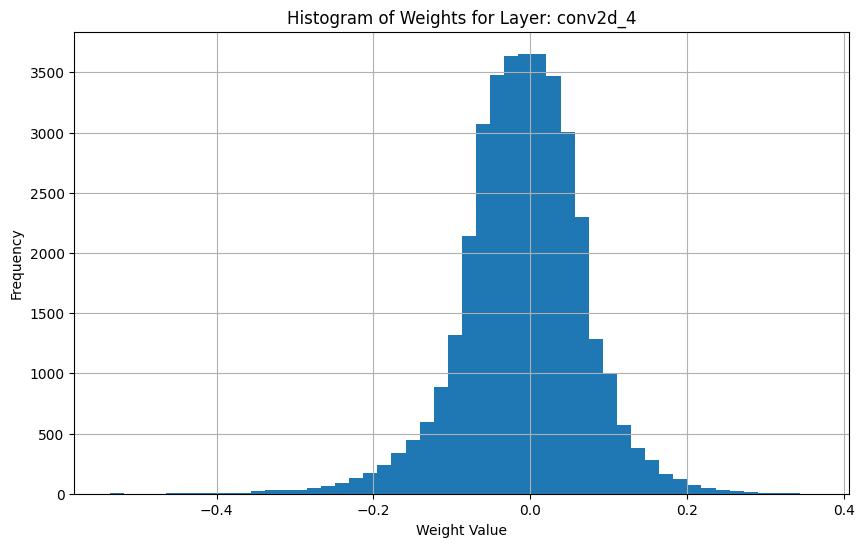

conv2d_4: float32, Shape: (3, 3, 64, 64), Memory: 144.00 KB


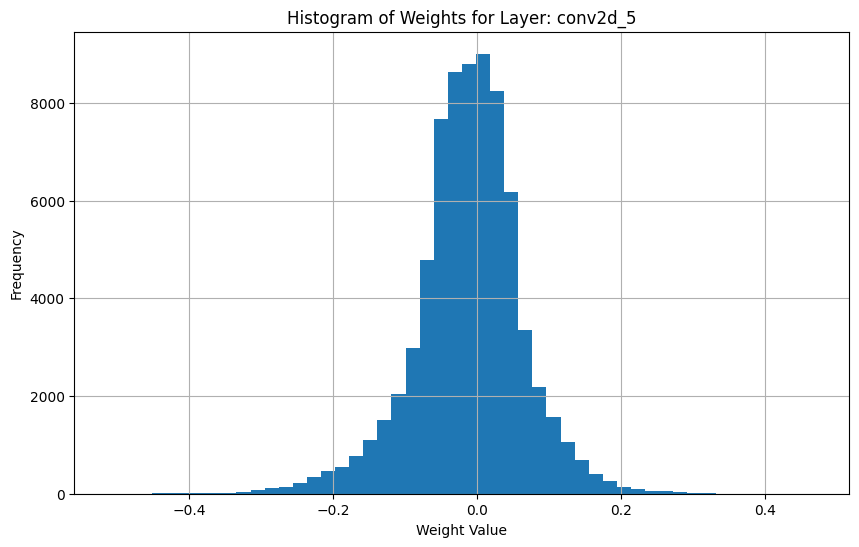

conv2d_5: float32, Shape: (3, 3, 64, 128), Memory: 288.00 KB


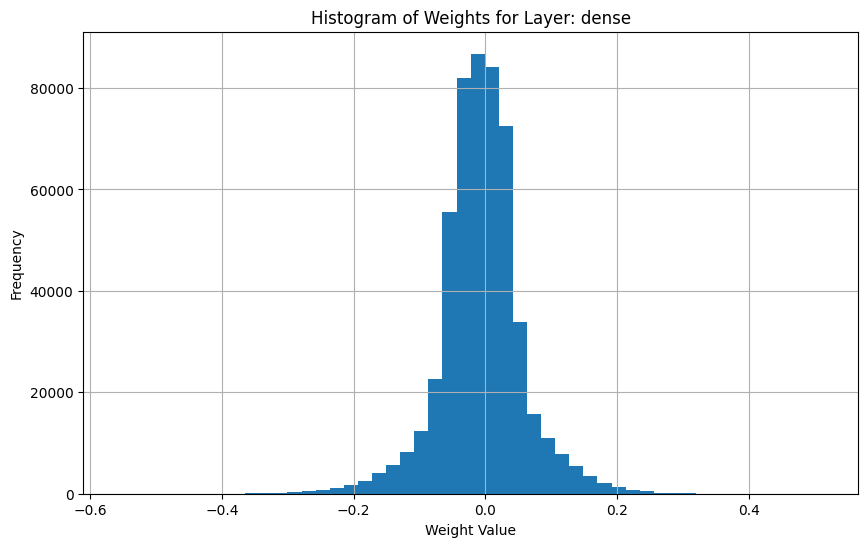

dense: float32, Shape: (2048, 256), Memory: 2048.00 KB


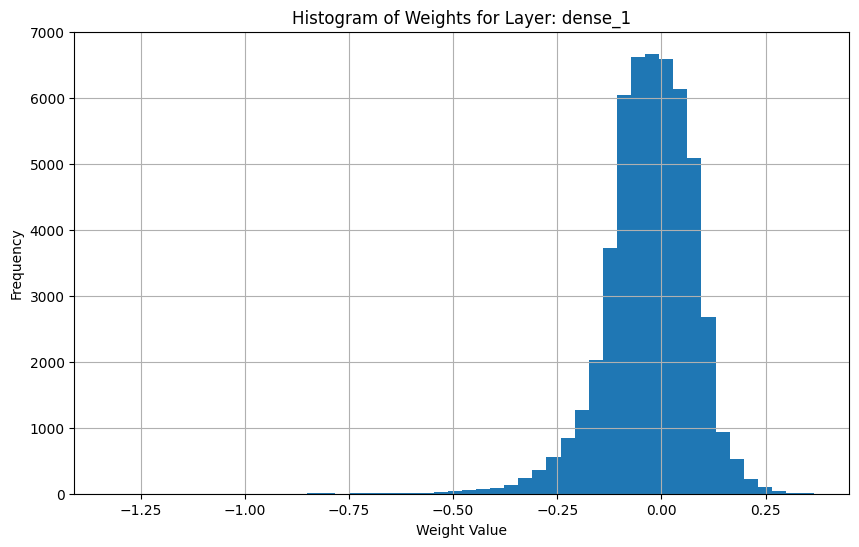

dense_1: float32, Shape: (256, 200), Memory: 200.00 KB


In [121]:
# #   print weigt details
# def print_weight_details(weights, layer_name):
#     dtype, shape = weights.dtype, weights.shape
#     num_params = np.prod(shape)
#     memory_bytes = num_params * 4
#     print(f"{layer_name}: {dtype}, Shape: {shape}, Memory: {memory_bytes / 1024:.2f} KB")

for layer in model.layers:
    if len(layer.get_weights()) == 0:
        continue
    weights = layer.get_weights()[0]
    weights_flat = weights.flatten()
    layer_name = layer.name

    plt.figure(figsize=(10, 6))
    plt.hist(weights_flat, bins=50)
    plt.title(f'Histogram of Weights for Layer: {layer_name}')
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    print_weight_details(weights, layer_name)

In [122]:
# Explore new models to find a higher-accuracy model. Does the new model require more or less time?